In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [16]:
df = pd.read_csv('account_activity.csv')
df.head()

,CustomerID,AccountBalance,LastLogin
0,1001,9507.272060,2022-01-01
1,1002,7408.704536,2022-01-02
2,1003,1715.321989,2022-01-03
3,1004,3101.509134,2022-01-04
4,1005,5405.766914,2022-01-05


In [22]:
account_activity = pd.read_csv('account_activity.csv')
amount_data = pd.read_csv('amount_data.csv')
anomaly_scores = pd.read_csv('anomaly_scores.csv')
customer_data = pd.read_csv('customer_data.csv')
fraud_indicators = pd.read_csv('fraud_indicators.csv')
merchant_data = pd.read_csv('merchant_data.csv')
suspicious_activity = pd.read_csv('suspicious_activity.csv')
transaction_category_labels = pd.read_csv('transaction_category_labels.csv')
transaction_metadata = pd.read_csv('transaction_metadata.csv')
transaction_records = pd.read_csv('transaction_records.csv')

In [23]:
data = [account_activity, amount_data, anomaly_scores, customer_data, fraud_indicators, merchant_data, suspicious_activity, transaction_category_labels, transaction_metadata, transaction_records]

In [25]:
for df in data:
    print(df.head())

   CustomerID  AccountBalance   LastLogin
0        1001     9507.272060  2022-01-01
1        1002     7408.704536  2022-01-02
2        1003     1715.321989  2022-01-03
3        1004     3101.509134  2022-01-04
4        1005     5405.766914  2022-01-05
   TransactionID  TransactionAmount
0              1          79.413607
1              2          12.053087
2              3          33.310357
3              4          46.121117
4              5          54.051618
   TransactionID  AnomalyScore
0              1      0.686699
1              2      0.081749
2              3      0.023857
3              4      0.876994
4              5      0.034059
   CustomerID           Name  Age       Address
0        1001  Customer 1001   54  Address 1001
1        1002  Customer 1002   35  Address 1002
2        1003  Customer 1003   40  Address 1003
3        1004  Customer 1004   30  Address 1004
4        1005  Customer 1005   46  Address 1005
   TransactionID  FraudIndicator
0              1         

In [26]:
customer_data = pd.merge(customer_data, account_activity, on='CustomerID')
customer_data = pd.merge(customer_data, suspicious_activity, on='CustomerID')
customer_data

,CustomerID,Name,Age,Address,AccountBalance,LastLogin,SuspiciousFlag
0,1001,Customer 1001,54,Address 1001,9507.272060,2022-01-01,0
1,1002,Customer 1002,35,Address 1002,7408.704536,2022-01-02,0
2,1003,Customer 1003,40,Address 1003,1715.321989,2022-01-03,0
3,1004,Customer 1004,30,Address 1004,3101.509134,2022-01-04,0
4,1005,Customer 1005,46,Address 1005,5405.766914,2022-01-05,0
...,...,...,...,...,...,...,...
995,1996,Customer 1996,33,Address 1996,8523.485163,2024-09-22,0
996,1997,Customer 1997,58,Address 1997,9255.451757,2024-09-23,0
997,1998,Customer 1998,25,Address 1998,9148.652759,2024-09-24,0
998,1999,Customer 1999,57,Address 1999,7376.854107,2024-09-25,0


In [28]:
transaction_data1 = pd.merge(fraud_indicators, transaction_category_labels, on='TransactionID')
transaction_data2 = pd.merge(amount_data, anomaly_scores, on='TransactionID')
transaction_data3 = pd.merge(transaction_metadata,transaction_records, on='TransactionID')
transaction_data = pd.merge(transaction_data1, transaction_data2,on="TransactionID")
transaction_data = pd.merge(transaction_data, transaction_data3,on="TransactionID")

In [29]:
transaction_data

,TransactionID,FraudIndicator,Category,TransactionAmount,AnomalyScore,Timestamp,MerchantID,Amount,CustomerID
0,1,0,Other,79.413607,0.686699,2022-01-01 00:00:00,2701,55.530334,1952
1,2,0,Online,12.053087,0.081749,2022-01-01 01:00:00,2070,12.881180,1027
2,3,0,Travel,33.310357,0.023857,2022-01-01 02:00:00,2238,50.176322,1955
3,4,0,Travel,46.121117,0.876994,2022-01-01 03:00:00,2879,41.634001,1796
4,5,0,Other,54.051618,0.034059,2022-01-01 04:00:00,2966,78.122853,1946
...,...,...,...,...,...,...,...,...,...
995,996,0,Food,89.457059,0.266778,2022-02-11 11:00:00,2150,19.876750,1411
996,997,0,Retail,47.958030,0.512483,2022-02-11 12:00:00,2888,96.299792,1566
997,998,0,Food,64.210046,0.367740,2022-02-11 13:00:00,2037,75.164459,1654
998,999,0,Travel,64.684167,0.960364,2022-02-11 14:00:00,2629,93.633040,1928


In [31]:
customer_data.info()
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      1000 non-null   int64  
 1   Name            1000 non-null   object 
 2   Age             1000 non-null   int64  
 3   Address         1000 non-null   object 
 4   AccountBalance  1000 non-null   float64
 5   LastLogin       1000 non-null   object 
 6   SuspiciousFlag  1000 non-null   int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      1000 non-null   int64  
 1   FraudIndicator     1000 non-null   int64  
 2   Category           1000 non-null   object 
 3   TransactionAmount  1000 non-null   float64
 4   AnomalyScore       1000 non-n

In [33]:
data = pd.merge(transaction_data, customer_data, on='CustomerID')
data 

,TransactionID,FraudIndicator,Category,TransactionAmount,AnomalyScore,Timestamp,MerchantID,Amount,CustomerID,Name,Age,Address,AccountBalance,LastLogin,SuspiciousFlag
0,1,0,Other,79.413607,0.686699,2022-01-01 00:00:00,2701,55.530334,1952,Customer 1952,50,Address 1952,2869.689912,2024-08-09,0
1,2,0,Online,12.053087,0.081749,2022-01-01 01:00:00,2070,12.881180,1027,Customer 1027,46,Address 1027,9527.947107,2022-01-27,0
2,3,0,Travel,33.310357,0.023857,2022-01-01 02:00:00,2238,50.176322,1955,Customer 1955,34,Address 1955,9288.355525,2024-08-12,0
3,4,0,Travel,46.121117,0.876994,2022-01-01 03:00:00,2879,41.634001,1796,Customer 1796,33,Address 1796,5588.049942,2024-03-06,0
4,5,0,Other,54.051618,0.034059,2022-01-01 04:00:00,2966,78.122853,1946,Customer 1946,18,Address 1946,7324.785332,2024-08-03,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,0,Food,89.457059,0.266778,2022-02-11 11:00:00,2150,19.876750,1411,Customer 1411,19,Address 1411,1290.323059,2023-02-15,0
996,997,0,Retail,47.958030,0.512483,2022-02-11 12:00:00,2888,96.299792,1566,Customer 1566,39,Address 1566,7067.831609,2023-07-20,0
997,998,0,Food,64.210046,0.367740,2022-02-11 13:00:00,2037,75.164459,1654,Customer 1654,51,Address 1654,9088.738359,2023-10-16,0
998,999,0,Travel,64.684167,0.960364,2022-02-11 14:00:00,2629,93.633040,1928,Customer 1928,60,Address 1928,9352.655675,2024-07-16,0


In [36]:
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      1000 non-null   int64  
 1   FraudIndicator     1000 non-null   int64  
 2   Category           1000 non-null   object 
 3   TransactionAmount  1000 non-null   float64
 4   AnomalyScore       1000 non-null   float64
 5   Timestamp          1000 non-null   object 
 6   MerchantID         1000 non-null   int64  
 7   Amount             1000 non-null   float64
 8   CustomerID         1000 non-null   int64  
 9   Name               1000 non-null   object 
 10  Age                1000 non-null   int64  
 11  Address            1000 non-null   object 
 12  AccountBalance     1000 non-null   float64
 13  LastLogin          1000 non-null   object 
 14  SuspiciousFlag     1000 non-null   int64  
dtypes: float64(4), int64(6), object(5)
memory usage: 117.3+ KB


,TransactionID,FraudIndicator,TransactionAmount,AnomalyScore,MerchantID,Amount,CustomerID,Age,AccountBalance,SuspiciousFlag
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,0.045000,55.853826,0.492282,2504.701000,55.394871,1496.626000,39.848000,5715.455931,0.025000
std,288.819436,0.207408,26.093606,0.288423,288.414883,25.070809,289.229047,13.074932,2540.517262,0.156203
min,1.000000,0.000000,10.057864,0.000234,2001.000000,10.006933,1001.000000,18.000000,1056.301181,0.000000
25%,250.750000,0.000000,33.875129,0.251802,2254.500000,34.502315,1239.000000,29.000000,3489.554711,0.000000
50%,500.500000,0.000000,55.958313,0.490242,2500.500000,57.844325,1501.000000,39.000000,5753.007775,0.000000
75%,750.250000,0.000000,77.589391,0.741888,2761.250000,75.858576,1739.250000,51.000000,7925.710167,0.000000
max,1000.000000,1.000000,99.784323,0.999047,3000.000000,99.887410,2000.000000,64.000000,9999.776239,1.000000


In [38]:
numerical_features = data.select_dtypes(include=['number']).columns.to_list()
categorical_features = data.select_dtypes(include=['object']).columns.to_list()
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)


Numerical Features: ['TransactionID', 'FraudIndicator', 'TransactionAmount', 'AnomalyScore', 'MerchantID', 'Amount', 'CustomerID', 'Age', 'AccountBalance', 'SuspiciousFlag']
Categorical Features: ['Category', 'Timestamp', 'Name', 'Address', 'LastLogin']


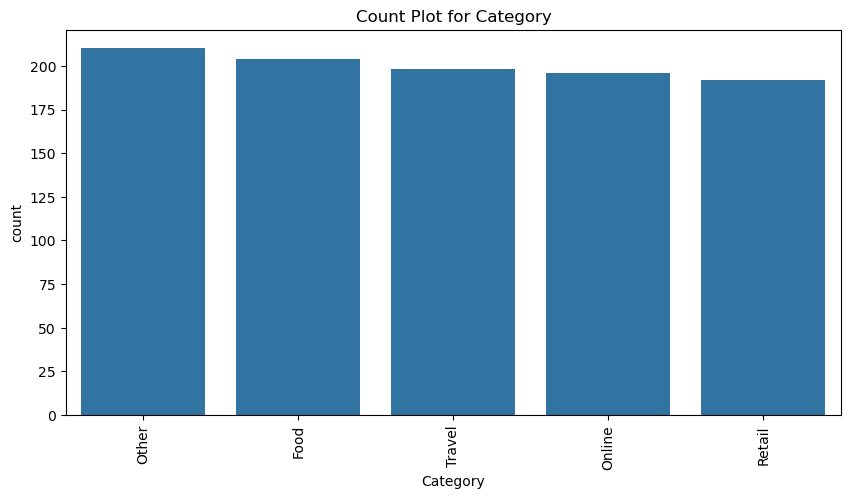

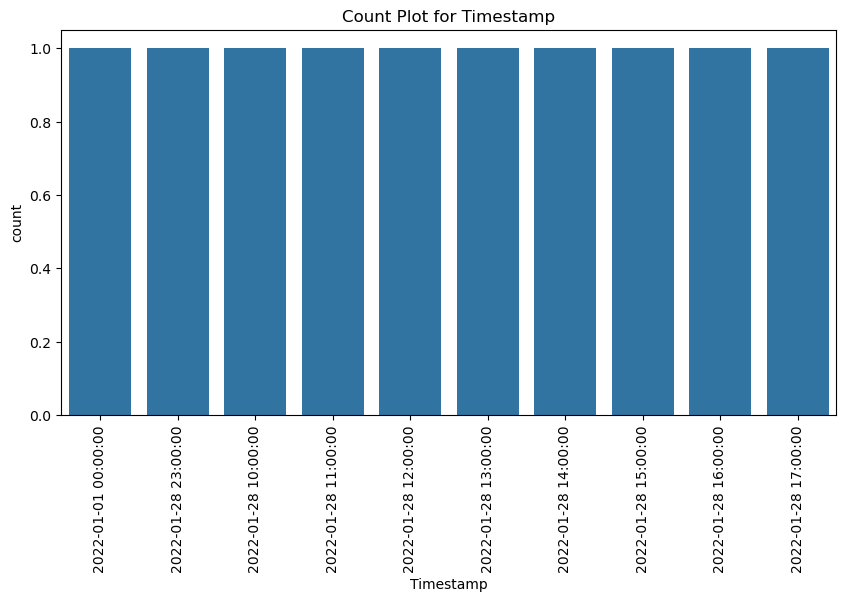

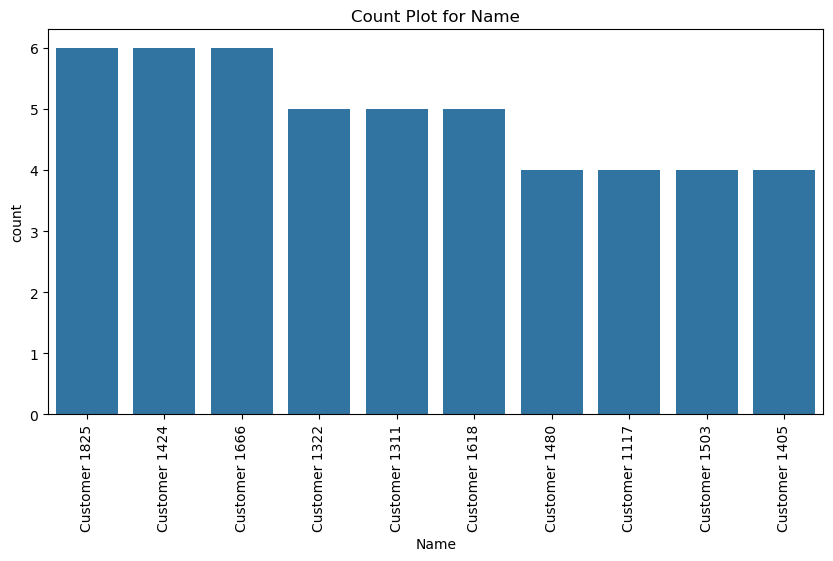

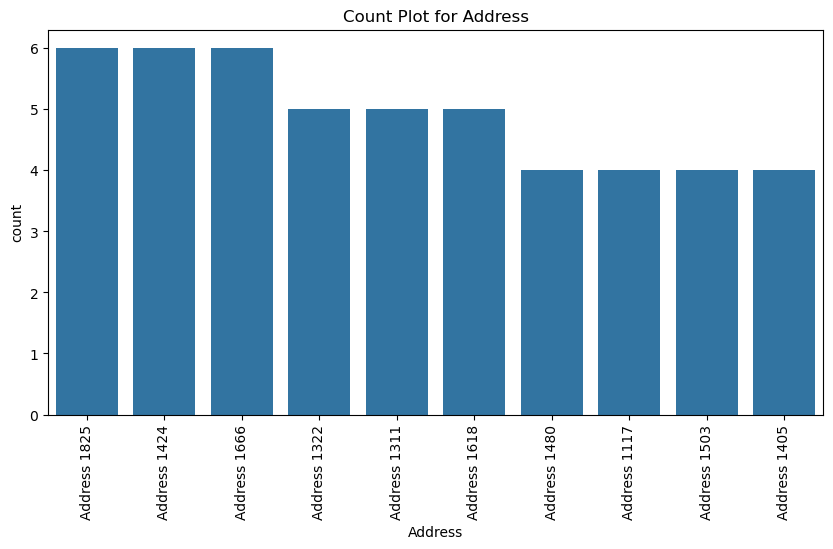

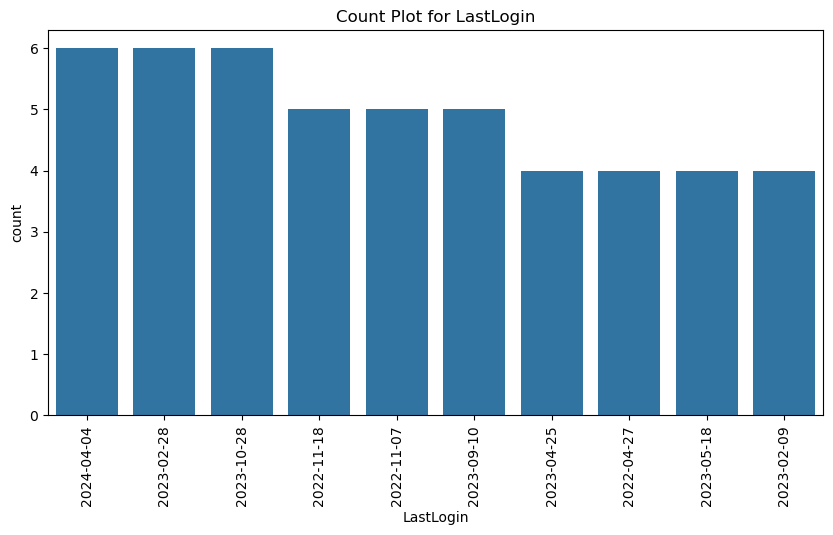

In [ ]:
for column in data.columns:
    if data[column].dtype == 'object':  # Check if the column has a categorical data type
        top_10_values = data[column].value_counts().head(10)  # Get the first 10 unique values and their counts
        plt.figure(figsize=(10, 5))  # Adjust the figure size if needed
        sns.countplot(x=column, data=data, order=top_10_values.index)
        plt.title(f'Count Plot for {column}')
        plt.xticks(rotation=90)  # Rotate x-axis labels if they are long
        plt.show()
        
        
# We do all this to understand the data and its distribution. 
# We can see that there are some categorical features that have a lot of unique values. 
# We will need to encode these features before we can use them in our model. 
# We will also need to handle missing values and outliers.

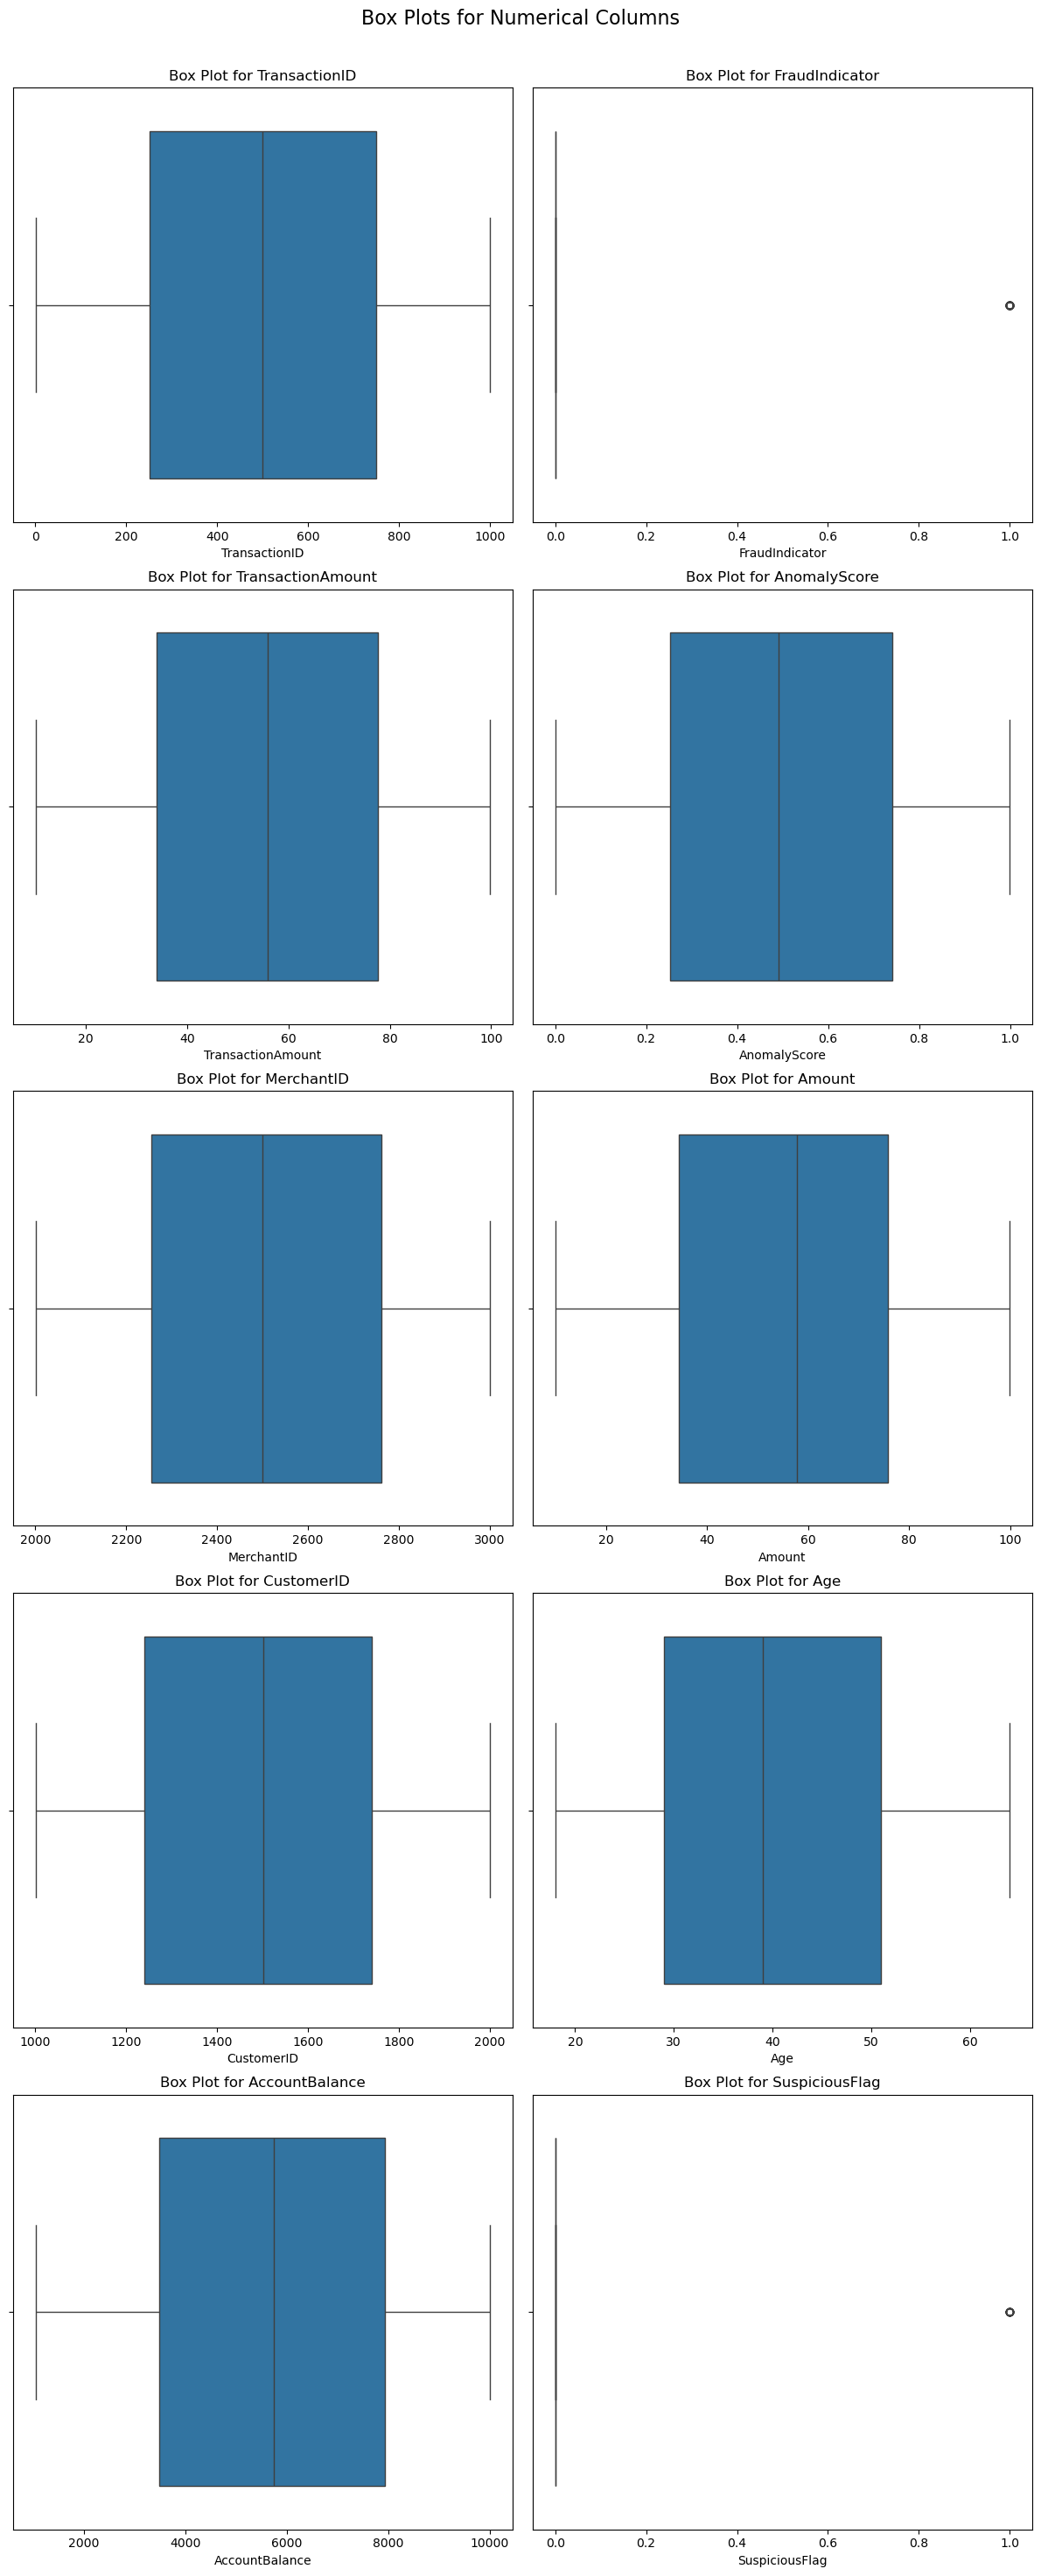

In [42]:
num_cols = len(data.select_dtypes(include=['number']).columns) # calculate the number of numerical columns
# In order to create a grid of plots, we need to determine the number of rows and columns for the grid.

# calculate the number of rows and columns for subplots
num_rows = (num_cols // 2) + (num_cols % 2)  # two plots per row, add an extra row if odd number of columns

# create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 6*num_rows))
fig.suptitle("Box Plots for Numerical Columns", fontsize=16)

# Loop through each numerical column and create a box plot

for i , column in enumerate(data.select_dtypes(include=['number']).columns):
    row = i // 2 # calculate the row index for the subplot
    col = i % 2 # calculate the column index for the subplot
    sns.boxplot(x=data[column], ax=axes[row, col]) # create a box plot for the current numerical column
    axes[row, col].set_title(f'Box Plot for {column}') # set the title for the subplot
    
if num_cols % 2 != 0: # if the number of numerical columns is odd
    fig.delaxes(axes[-1, -1]) # remove the last empty subplot

plt.tight_layout() # adjust the layout to prevent overlap
plt.subplots_adjust(top=0.95) # adjust the top spacing to accommodate the suptitle
plt.show() # display the plots

C:\Users\benfi\AppData\Local\Temp\ipykernel_21864\2890466583.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SuspiciousFlag', data=data, palette='Set2')


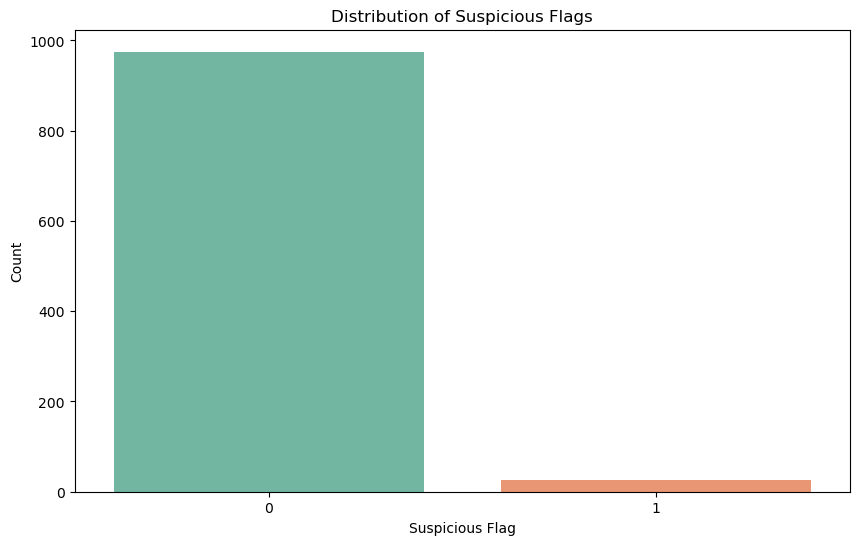

In [49]:
# For SuspiciousFlag, we should use a count plot to visualize the distribution of the two classes (0 and 1).
# This will help us understand if the dataset is imbalanced or not.

plt.figure(figsize=(10, 6))
sns.countplot(x='SuspiciousFlag', data=data, palette='Set2')
plt.title('Distribution of Suspicious Flags')
plt.xlabel('Suspicious Flag')
plt.ylabel('Count')
plt.show()


Isto diz nos que o dataset está muito desiquilibrado (muitos 0 poucos 1 )
Temos que arranjar forma de os equilibrar um pouco

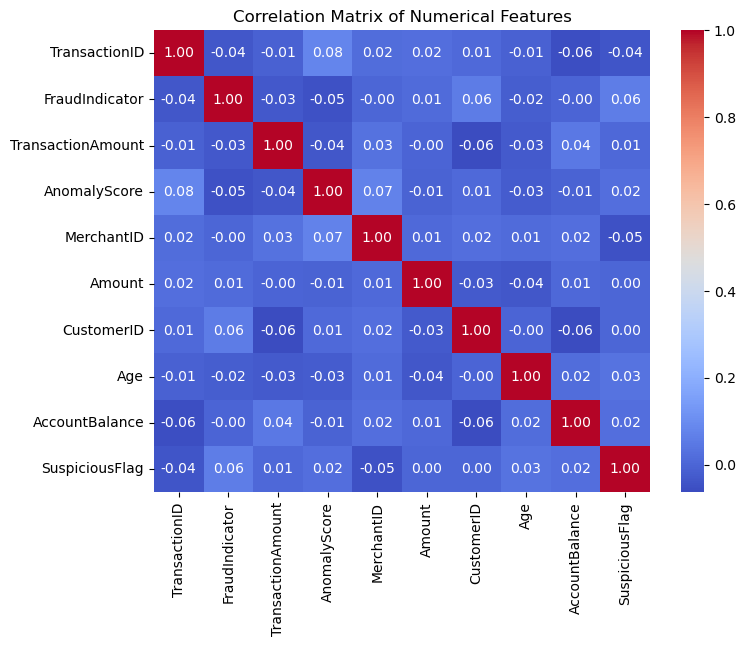

In [51]:
# Lets do Correlation beetween numerical features. 
# This will help us understand the relationship between the features 
# and the target variable (SuspiciousFlag). We can use a heatmap to visualize the correlation matrix.

numeric_data = data.select_dtypes(include=['number'])  # Select only numerical columns

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Podemos ver que as correlações são todas muito fracas (0,00-0,19) na escala de Pearson